In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from itertools import combinations
import re
from collections import defaultdict
from tqdm import tqdm
tqdm.pandas()

df_final = pd.read_csv('../data/df_final_prepared.csv')


ЗАДАЧА 2.2: ОБУЧЕНИЕ WORD2VEC (БЕЙЗЛАЙН)

 1. ЗАГРУЗКА ДАННЫХ
--------------------------------------------------------------------------------
 Загружено:
   - Корзин: 49,997
   - Уникальных товаров: 27,220
   - Метаданных: 27,220

 2. ПОДГОТОВКА ДАННЫХ ДЛЯ WORD2VEC
--------------------------------------------------------------------------------
 Преобразовано в строковые ID
   Пример первой корзины (ID): ['0', '1066', '1066', '2481', '12992', '19561', '19669', '20039', '21493', '24052']

 3. ОБУЧЕНИЕ WORD2VEC
--------------------------------------------------------------------------------
 Гиперпараметры:
   vector_size: 64
   window: 10
   min_count: 5
   epochs: 10
   sg (Skip-gram): 1
   negative sampling: 5

 Обучение модели (может занять 1-3 минуты)...
 Модель обучена!
   Словарь содержит 15045 товаров
   (отфильтровано 12175 редких товаров с count < 5)

 4. ИЗВЛЕЧЕНИЕ EMBEDDINGS
--------------------------------------------------------------------------------
 Извлечено embeddin

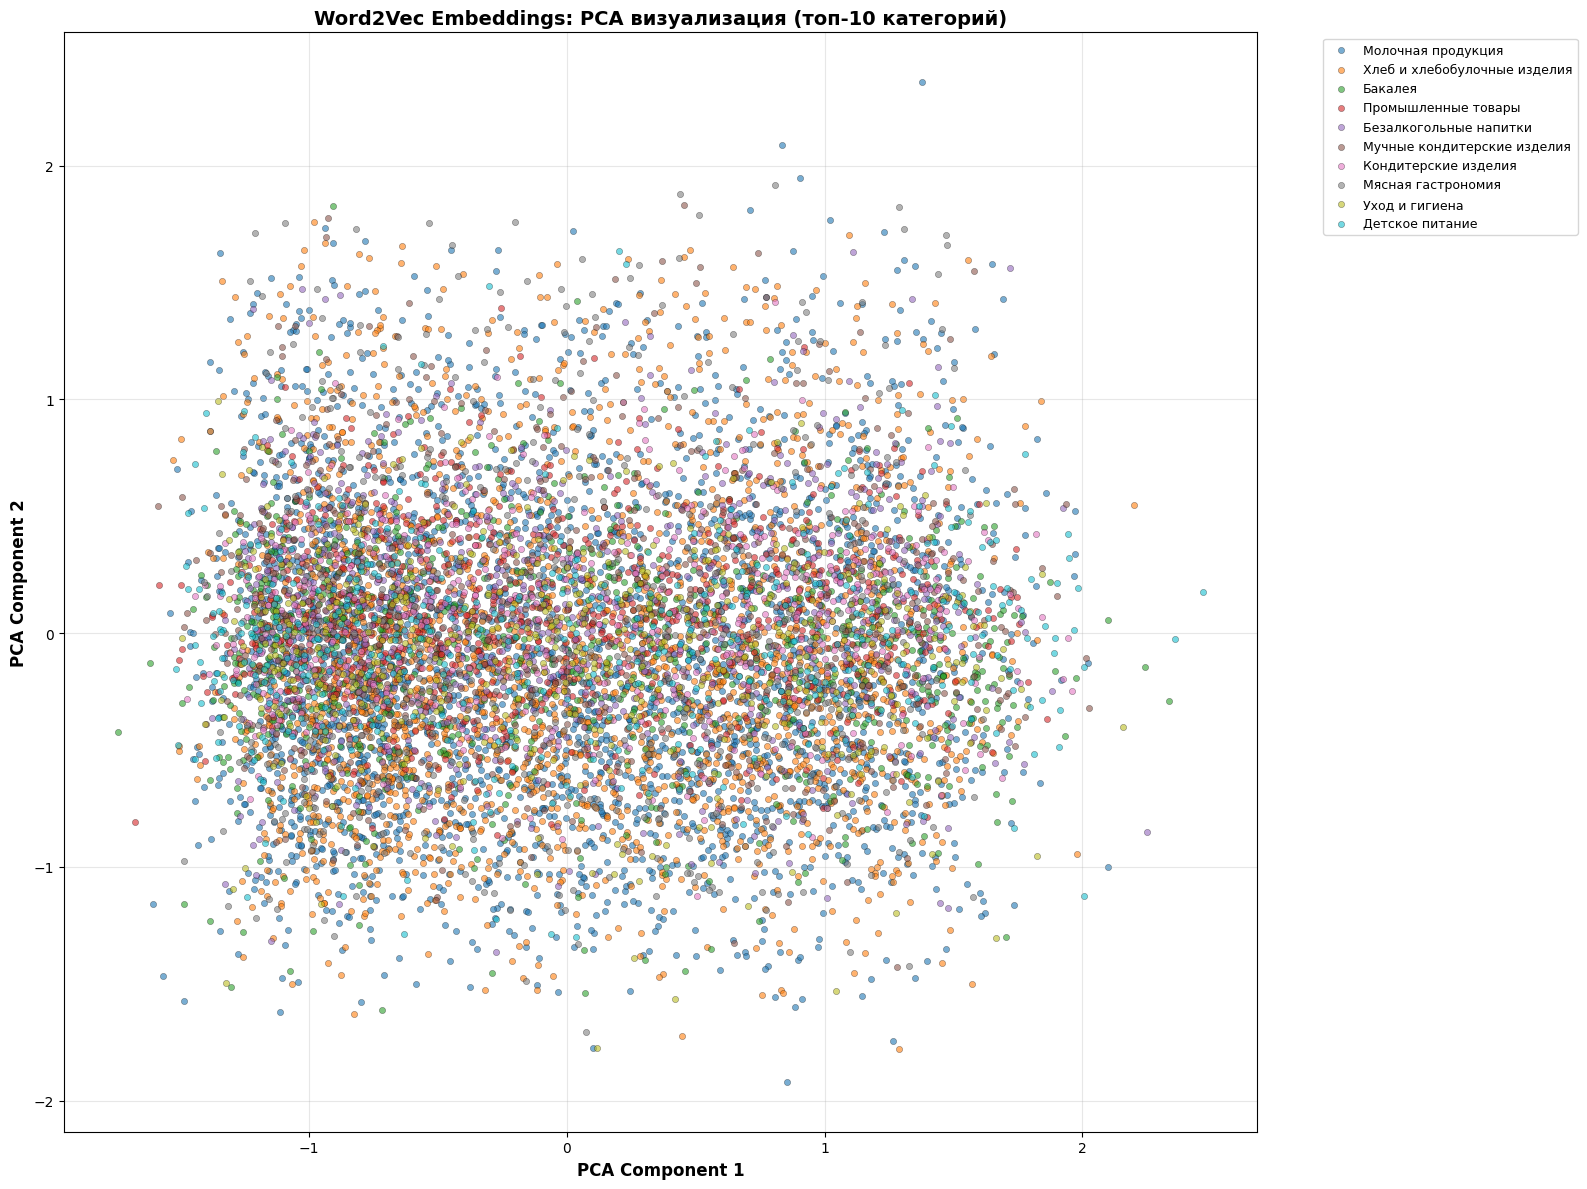



 7. СОХРАНЕНИЕ
--------------------------------------------------------------------------------
 Сохранено: ../data/word2vec_model.bin
 Сохранено: ../data/embeddings_matrix.npy
 Сохранено: ../data/embeddings_with_metadata.csv
 Сохранено: ../data/embedding_product_ids.pkl

 ЗАДАЧА 2.2 ЗАВЕРШЕНА!

 ИТОГИ:
   - Обучена модель Word2Vec (64-мерные embeddings)
   - Словарь: 15045 товаров
   - Explained variance (PCA 2D): 13.99%

 Сохранённые файлы:
   - word2vec_model.bin
   - embeddings_matrix.npy
   - embeddings_with_metadata.csv
   - word2vec_pca_visualization.png


In [ ]:
import pickle
import numpy as np
import pandas as pd
from gensim.models import Word2Vec
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

print("\n" + "=" * 80)
print("ЗАДАЧА 2.2: ОБУЧЕНИЕ WORD2VEC (БЕЙЗЛАЙН)")
print("=" * 80)

# 1. ЗАГРУЗКА ПОДГОТОВЛЕННЫХ ДАННЫХ

print("\n 1. ЗАГРУЗКА ДАННЫХ")
print("-" * 80)

# Загружаем baskets с product_id
with open('../data/baskets_product_id.pkl', 'rb') as f:
    baskets = pickle.load(f)

# Загружаем метаданные товаров
with open('../data/product_metadata.pkl', 'rb') as f:
    product_metadata = pickle.load(f)

# Загружаем уникальные товары
unique_products = pd.read_csv('../data/unique_products.csv')

print(f" Загружено:")
print(f"   - Корзин: {len(baskets):,}")
print(f"   - Уникальных товаров: {len(unique_products):,}")
print(f"   - Метаданных: {len(product_metadata):,}")

# 2. ПОДГОТОВКА ДАННЫХ ДЛЯ WORD2VEC

print("\n 2. ПОДГОТОВКА ДАННЫХ ДЛЯ WORD2VEC")
print("-" * 80)

# Word2Vec требует строковые ID (не int)
baskets_str = [[str(pid) for pid in basket] for basket in baskets]

print(f" Преобразовано в строковые ID")
print(f"   Пример первой корзины (ID): {baskets_str[0][:10]}")

# 3. ОБУЧЕНИЕ WORD2VEC

print("\n 3. ОБУЧЕНИЕ WORD2VEC")
print("-" * 80)

# Гиперпараметры (на основе De Swardt, 2021)
VECTOR_SIZE = 64      # размер эмбеддинга (64 измерения)
WINDOW = 10           # окно контекста (10 товаров вокруг)
MIN_COUNT = 5         # минимальная частота товара (фильтр редких)
EPOCHS = 10           # количество эпох обучения
WORKERS = 4           # количество потоков
SG = 1                # Skip-gram (1) или CBOW (0)
NEGATIVE = 5          # negative sampling

print(f" Гиперпараметры:")
print(f"   vector_size: {VECTOR_SIZE}")
print(f"   window: {WINDOW}")
print(f"   min_count: {MIN_COUNT}")
print(f"   epochs: {EPOCHS}")
print(f"   sg (Skip-gram): {SG}")
print(f"   negative sampling: {NEGATIVE}")

print(f"\n Обучение модели (может занять 1-3 минуты)...")

# Обучаем модель
model = Word2Vec(
    sentences=baskets_str,
    vector_size=VECTOR_SIZE,
    window=WINDOW,
    min_count=MIN_COUNT,
    epochs=EPOCHS,
    workers=WORKERS,
    sg=SG,
    negative=NEGATIVE,
    seed=42
)

print(f" Модель обучена!")
print(f"   Словарь содержит {len(model.wv)} товаров")
print(f"   (отфильтровано {len(unique_products) - len(model.wv)} редких товаров с count < {MIN_COUNT})")

# 4. ИЗВЛЕЧЕНИЕ EMBEDDINGS
# 

print("\n 4. ИЗВЛЕЧЕНИЕ EMBEDDINGS")
print("-" * 80)

# Получаем embeddings для всех товаров в словаре
embeddings_dict = {}
for product_id_str in model.wv.index_to_key:
    product_id = int(product_id_str)
    embeddings_dict[product_id] = model.wv[product_id_str]

# Конвертируем в numpy array и DataFrame
product_ids = list(embeddings_dict.keys())
embeddings_matrix = np.array([embeddings_dict[pid] for pid in product_ids])

print(f" Извлечено embeddings:")
print(f"   Shape: {embeddings_matrix.shape}")
print(f"   (товаров × измерений)")

# Создаём DataFrame с embeddings
embeddings_df = pd.DataFrame(
    embeddings_matrix,
    index=product_ids,
    columns=[f'dim_{i}' for i in range(VECTOR_SIZE)]
)

# Добавляем метаданные
embeddings_df['product_id'] = embeddings_df.index
embeddings_df = embeddings_df.merge(
    unique_products,
    on='product_id',
    how='left'
)

print(f"\n DataFrame с embeddings:")
print(f"   Размер: {embeddings_df.shape}")
print(f"   Столбцы: {list(embeddings_df.columns[:5])} + метаданные")

# 5. ПЕРВИЧНАЯ ВАЛИДАЦИЯ

print("\n\n 5. ПЕРВИЧНАЯ ВАЛИДАЦИЯ")
print("-" * 80)

# 5.1: Similarity test (найти похожие товары)
print("\n5.1 Тест similarity:")

# Выбираем несколько товаров для теста
test_products = [
    ("БАНАНЫ", unique_products[unique_products['name'].str.contains('БАНАНЫ', case=False, na=False)].iloc[0]['product_id'] if len(unique_products[unique_products['name'].str.contains('БАНАНЫ', case=False, na=False)]) > 0 else None),
    ("Молоко", unique_products[unique_products['name'].str.contains('Молоко', case=False, na=False)].iloc[0]['product_id'] if len(unique_products[unique_products['name'].str.contains('Молоко', case=False, na=False)]) > 0 else None),
    ("Хлеб", unique_products[unique_products['name'].str.contains('Хлеб', case=False, na=False)].iloc[0]['product_id'] if len(unique_products[unique_products['name'].str.contains('Хлеб', case=False, na=False)]) > 0 else None),
]

for test_name, test_pid in test_products:
    if test_pid is None or str(test_pid) not in model.wv:
        print(f"\n  {test_name}: не найден в словаре")
        continue
    
    # Получаем топ-5 похожих товаров
    similar = model.wv.most_similar(str(test_pid), topn=5)
    
    print(f"\n Товар: {test_name} (ID: {test_pid})")
    print(f"   Полное название: {product_metadata[test_pid]['name'][:60]}")
    print(f"\n   Топ-5 похожих товаров:")
    
    for i, (similar_id_str, score) in enumerate(similar, 1):
        similar_id = int(similar_id_str)
        similar_name = product_metadata[similar_id]['name']
        similar_cat = product_metadata[similar_id]['art_grp_lvl_0_name']
        print(f"   {i}. [{score:.3f}] {similar_name[:50]} ({similar_cat})")

# 6. ВИЗУАЛИЗАЦИЯ (PCA 2D)

print("\n\n 6. ВИЗУАЛИЗАЦИЯ (PCA 2D)")
print("-" * 80)

print(" Применяем PCA для снижения размерности до 2D...")

# PCA: 64 → 2
pca = PCA(n_components=2, random_state=42)
embeddings_2d = pca.fit_transform(embeddings_matrix)

print(f" PCA завершена")
print(f"   Explained variance: {pca.explained_variance_ratio_.sum():.2%}")

# Добавляем координаты в DataFrame
embeddings_df['pca_0'] = embeddings_2d[:, 0]
embeddings_df['pca_1'] = embeddings_2d[:, 1]

# График: PCA по категориям (lvl_0)
print("\n Строим график...")

fig, ax = plt.subplots(figsize=(16, 12))

# Берём топ-10 категорий для визуализации
top_categories = embeddings_df['art_grp_lvl_0_name'].value_counts().head(10).index

# Фильтруем только топ-10
df_plot = embeddings_df[embeddings_df['art_grp_lvl_0_name'].isin(top_categories)]

# Scatter plot с цветами по категориям
for cat in top_categories:
    mask = df_plot['art_grp_lvl_0_name'] == cat
    ax.scatter(
        df_plot.loc[mask, 'pca_0'],
        df_plot.loc[mask, 'pca_1'],
        label=cat[:30],
        alpha=0.6,
        s=20,
        edgecolors='black',
        linewidths=0.3
    )

ax.set_xlabel('PCA Component 1', fontsize=12, fontweight='bold')
ax.set_ylabel('PCA Component 2', fontsize=12, fontweight='bold')
ax.set_title('Word2Vec Embeddings: PCA визуализация (топ-10 категорий)', 
             fontsize=14, fontweight='bold')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../data/word2vec_pca_visualization.png', dpi=300, bbox_inches='tight')
print(" График сохранён: ../data/word2vec_pca_visualization.png")
plt.show()

# 7. СОХРАНЕНИЕ МОДЕЛИ И EMBEDDINGS

print("\n\n 7. СОХРАНЕНИЕ")
print("-" * 80)

# Сохраняем модель Word2Vec
model.save('../data/word2vec_model.bin')
print(" Сохранено: ../data/word2vec_model.bin")

# Сохраняем embeddings (numpy)
np.save('../data/embeddings_matrix.npy', embeddings_matrix)
print(" Сохранено: ../data/embeddings_matrix.npy")

# Сохраняем embeddings с метаданными (CSV)
embeddings_df.to_csv('../data/embeddings_with_metadata.csv', index=False)
print(" Сохранено: ../data/embeddings_with_metadata.csv")

# Сохраняем product_ids (порядок важен!)
with open('../data/embedding_product_ids.pkl', 'wb') as f:
    pickle.dump(product_ids, f)
print(" Сохранено: ../data/embedding_product_ids.pkl")

print("\n" + "=" * 80)
print(" ЗАДАЧА 2.2 ЗАВЕРШЕНА!")
print("=" * 80)
print(f"\n ИТОГИ:")
print(f"   - Обучена модель Word2Vec ({VECTOR_SIZE}-мерные embeddings)")
print(f"   - Словарь: {len(model.wv)} товаров")
print(f"   - Explained variance (PCA 2D): {pca.explained_variance_ratio_.sum():.2%}")
print(f"\n Сохранённые файлы:")
print(f"   - word2vec_model.bin")
print(f"   - embeddings_matrix.npy")
print(f"   - embeddings_with_metadata.csv")
print(f"   - word2vec_pca_visualization.png")



 6.2 ВИЗУАЛИЗАЦИЯ (t-SNE 2D)
--------------------------------------------------------------------------------
 Применяем t-SNE
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 15045 samples in 0.001s...
[t-SNE] Computed neighbors for 15045 samples in 3.409s...
[t-SNE] Computed conditional probabilities for sample 1000 / 15045
[t-SNE] Computed conditional probabilities for sample 2000 / 15045
[t-SNE] Computed conditional probabilities for sample 3000 / 15045
[t-SNE] Computed conditional probabilities for sample 4000 / 15045
[t-SNE] Computed conditional probabilities for sample 5000 / 15045
[t-SNE] Computed conditional probabilities for sample 6000 / 15045
[t-SNE] Computed conditional probabilities for sample 7000 / 15045
[t-SNE] Computed conditional probabilities for sample 8000 / 15045
[t-SNE] Computed conditional probabilities for sample 9000 / 15045
[t-SNE] Computed conditional probabilities for sample 10000 / 15045
[t-SNE] Computed conditional probabilities for sample 1100

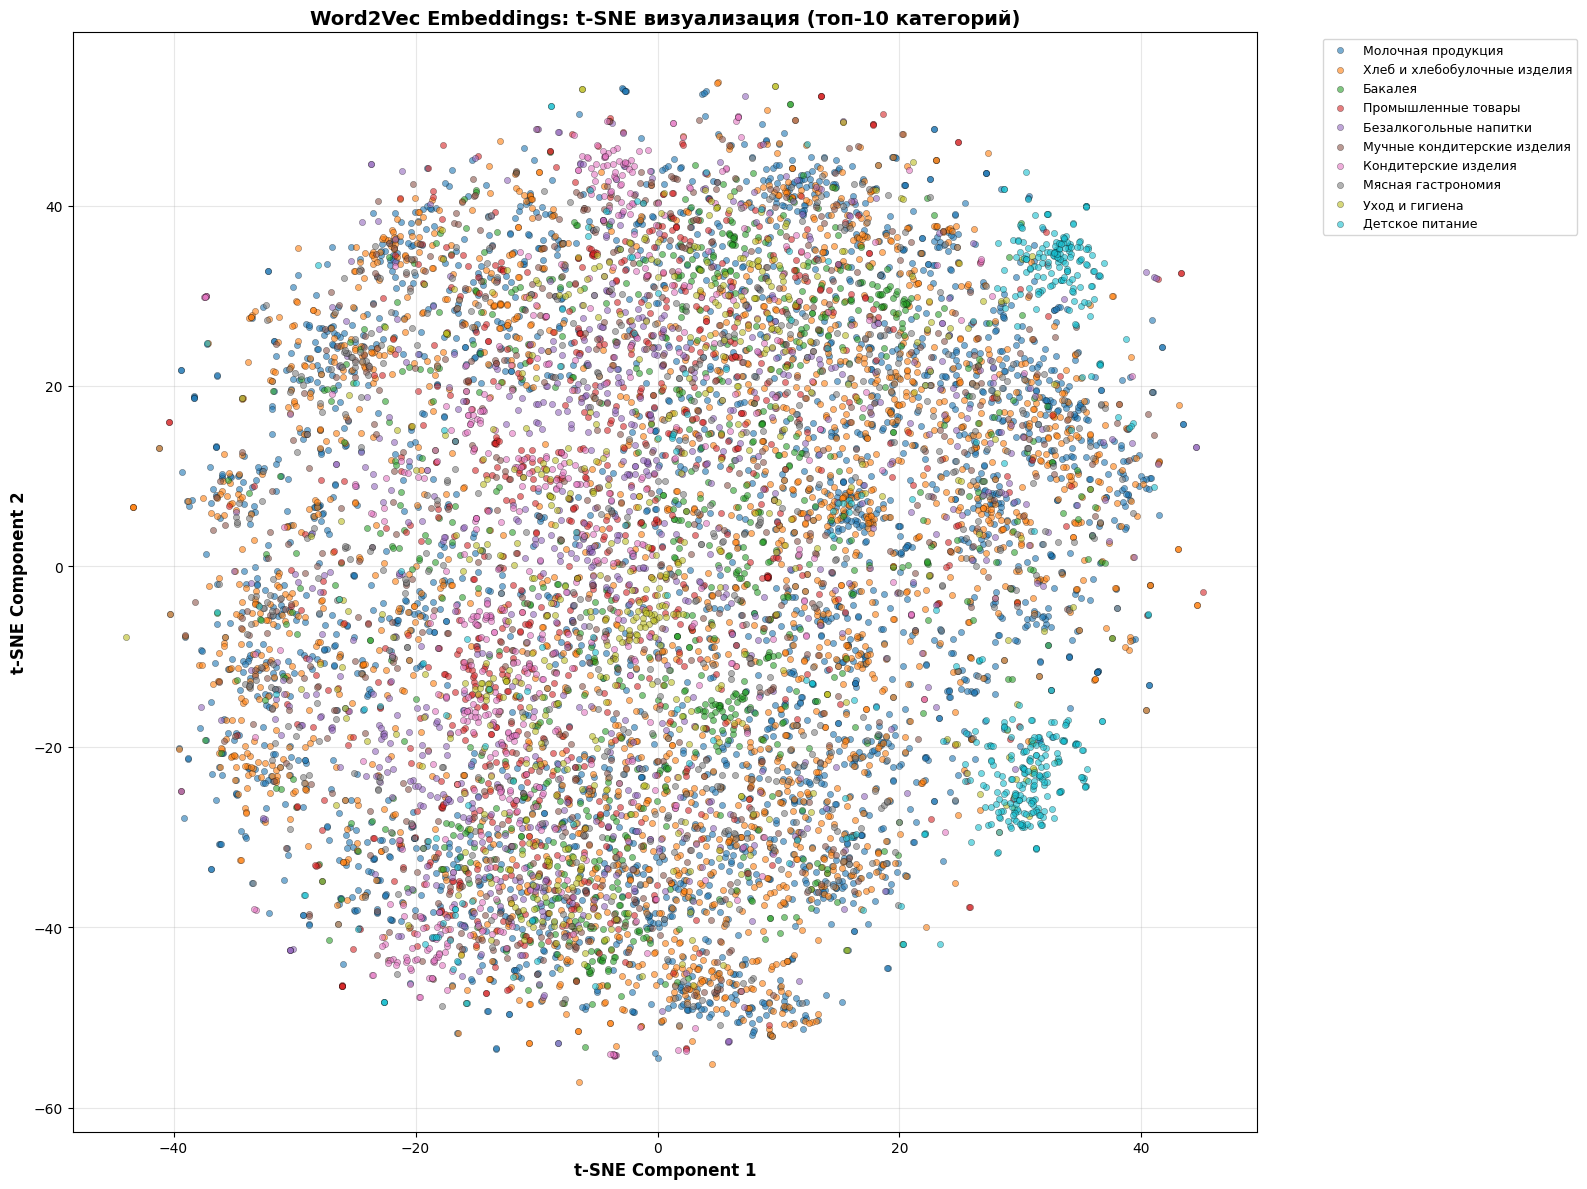

 Обновлено: ../data/embeddings_with_metadata.csv (добавлены t-SNE координаты)


In [ ]:
# 6.2. ВИЗУАЛИЗАЦИЯ (t-SNE 2D)

print("\n 6.2 ВИЗУАЛИЗАЦИЯ (t-SNE 2D)")
print("-" * 80)

from sklearn.manifold import TSNE

print(" Применяем t-SNE")

# t-SNE: 64 → 2
tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42,
    n_iter=1000,
    verbose=1
)
embeddings_2d_tsne = tsne.fit_transform(embeddings_matrix)

print(f" t-SNE завершена")

# Добавляем координаты в DataFrame
embeddings_df['tsne_0'] = embeddings_2d_tsne[:, 0]
embeddings_df['tsne_1'] = embeddings_2d_tsne[:, 1]

# График: t-SNE по категориям (lvl_0)
print("\n Строим график t-SNE...")

fig, ax = plt.subplots(figsize=(16, 12))

# Берём топ-10 категорий
top_categories = embeddings_df['art_grp_lvl_0_name'].value_counts().head(10).index
df_plot = embeddings_df[embeddings_df['art_grp_lvl_0_name'].isin(top_categories)]

# Scatter plot с цветами по категориям
for cat in top_categories:
    mask = df_plot['art_grp_lvl_0_name'] == cat
    ax.scatter(
        df_plot.loc[mask, 'tsne_0'],
        df_plot.loc[mask, 'tsne_1'],
        label=cat[:30],
        alpha=0.6,
        s=20,
        edgecolors='black',
        linewidths=0.3
    )

ax.set_xlabel('t-SNE Component 1', fontsize=12, fontweight='bold')
ax.set_ylabel('t-SNE Component 2', fontsize=12, fontweight='bold')
ax.set_title('Word2Vec Embeddings: t-SNE визуализация (топ-10 категорий)', 
             fontsize=14, fontweight='bold')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Сохраняем обновлённый DataFrame с t-SNE координатами
embeddings_df.to_csv('../data/embeddings_with_metadata.csv', index=False)
print(" Обновлено: ../data/embeddings_with_metadata.csv (добавлены t-SNE координаты)")


Что получилось  
Модель обучена успешно:  
15,045 товаров в словаре (из 27,220 после фильтрации min_count=5)  
64-мерные embeddings  
Embeddings содержат некоторую структуру:  
t-SNE визуализация показывает локальные сгущения товаров  
Некоторые товары из одной категории группируются вместе  
Что НЕ получилось  
Similarity тесты показывают смешивание substitutes и complements:  
БАНАНЫ → топ-5 похожих: Хлеб (0.703), Смесь перцев (0.702), Тунец (0.701)
Молоко → топ-5 похожих: Хлеб (0.739), Тетрадь (0.727), Газета (0.727)
Модель путает товары-заменители (substitutes) с товарами-дополнениями (complements)  

Визуализация не показывает чёткого разделения по категориям:  
PCA: explained variance 14% (первые 2 компоненты почти не несут информации)  
t-SNE: категории визуально перемешаны, нет чётких кластеров  
Линейная проекция не раскрывает структуру латентного пространства  
​
Word2Vec учится на co-occurrence, а не на semantic similarity:  
Модель кодирует "какие товары покупают вместе", а не "какие товары семантически похожи"  
Для розничных данных с импульсными покупками (газета + молоко у кассы) это приводит к шуму  
Embeddings не разделены (entangled) по факторам вариации (категория, цена, бренд и т.д.)  

**Вывод:**    
Word2Vec, как unsupervised метод на основе co-occurrence, захватывает паттерны совместных покупок, но не обеспечивает disentangled и интерпретируемые представления товаров. Это мотивирует применение архитектур с явным разделением факторов вариации (disentanglement) и alignment с текстовыми/категориальными атрибутами.nt с текстовыми/категориальными атрибутами.  



In [8]:
import random

def augment_baskets(baskets, n_shuffles=5):
    augmented = []
    for basket in baskets:
        basket = list(basket)
        for _ in range(n_shuffles):
            random.shuffle(basket)
            augmented.append(basket.copy())
    return augmented

baskets_aug = augment_baskets(baskets, n_shuffles=5)

In [9]:
from collections import Counter

item_counts = Counter([item for basket in baskets for item in basket])
top_items = [item for item, _ in item_counts.most_common(50)]

def popularity_recommend(k: int = 10):
    """
    Возвращает список самых популярных товаров (топ-k по частоте встречаемости).

    Функция использует глобальную переменную `top_items`, которая должна быть
    определена ранее как список товаров (ID или строк), отсортированных по убыванию
    частоты встречаемости во всех корзинах.

    Параметры
    ----------
    k : int, default=10
        Количество рекомендуемых товаров.

    Возвращает
    ----------
    list
        Список из первых `k` самых популярных товаров.
    """
    return top_items[:k]

In [10]:
from sklearn.model_selection import train_test_split

train_baskets, test_baskets = train_test_split(baskets, test_size=0.2, random_state=42)

In [11]:
from tqdm import tqdm
import numpy as np

def recall_at_k_random_holdout(model, test_baskets, k=10, random_state=42):
    """
    Recall@K для Word2Vec по схеме random leave-one-out:
    из каждой корзины случайно скрывается один товар,
    остальные товары используются как контекст.
    """
    rng = np.random.default_rng(random_state)
    recalls = []

    for basket in tqdm(test_baskets):
        basket = list(basket)

        # убираем дубли внутри корзины для честной multi-hot логики
        basket = list(dict.fromkeys(basket))

        if len(basket) < 2:
            continue

        target = str(rng.choice(basket))
        context = [str(x) for x in basket if str(x) != target]

        if len(context) == 0:
            continue

        scores = {}

        for item in model.wv.index_to_key:
            if item in context:
                continue

            score = 0.0
            for c in context:
                if c in model.wv:
                    score += model.wv.similarity(item, c)

            scores[item] = score

        top_k = sorted(scores, key=scores.get, reverse=True)[:k]
        recalls.append(int(target in top_k))

    return sum(recalls) / len(recalls) if recalls else 0.0

from tqdm import tqdm
import numpy as np

def recall_at_k_random_holdout(model, test_baskets, k=10, random_state=42):
    """
    Recall@K для Word2Vec по схеме random leave-one-out:
    из каждой корзины случайно скрывается один товар,
    остальные товары используются как контекст.
    """
    rng = np.random.default_rng(random_state)
    recalls = []

    for basket in tqdm(test_baskets):
        basket = list(basket)

        # убираем дубли внутри корзины для честной multi-hot логики
        basket = list(dict.fromkeys(basket))

        if len(basket) < 2:
            continue

        target = str(rng.choice(basket))
        context = [str(x) for x in basket if str(x) != target]

        if len(context) == 0:
            continue

        scores = {}

        for item in model.wv.index_to_key:
            if item in context:
                continue

            score = 0.0
            for c in context:
                if c in model.wv:
                    score += model.wv.similarity(item, c)

            scores[item] = score

        top_k = sorted(scores, key=scores.get, reverse=True)[:k]
        recalls.append(int(target in top_k))

    return sum(recalls) / len(recalls) if recalls else 0.0 

def popularity_recall_random_holdout(test_baskets, k=10, random_state=42):
    """
    Recall@K для popularity baseline по схеме random leave-one-out.
    """
    rng = np.random.default_rng(random_state)
    recalls = []

    for basket in tqdm(test_baskets):
        basket = list(basket)

        # убираем дубли
        basket = list(dict.fromkeys(basket))

        if len(basket) < 2:
            continue

        target = rng.choice(basket)
        context = [x for x in basket if x != target]

        if len(context) == 0:
            continue

        # исключаем уже увиденные товары из рекомендаций
        recs = [x for x in popularity_recommend(k=1000) if x not in context][:k]

        recalls.append(int(target in recs))

    return sum(recalls) / len(recalls) if recalls else 0.0


In [17]:
sample_test = random.sample(test_baskets, 3000)

print("Popularity Recall@10:", popularity_recall_random_holdout(sample_test, k=10, random_state=42))
print("Word2Vec Recall@10:", recall_at_k_random_holdout(model, sample_test, k=10, random_state=42))

100%|██████████| 3000/3000 [00:00<00:00, 22552.73it/s]


Popularity Recall@10: 0.05800542740841248


100%|██████████| 3000/3000 [2:04:29<00:00,  2.49s/it]  

Word2Vec Recall@10: 0.04172320217096336
